<a href="https://colab.research.google.com/github/Mufliha-Hafsyah/PCVK_Ganjil_2026/blob/main/Week5_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LAPORAN PRAKTIKUM <br> Pengolahan Citra dan Visi Komputer (PCVK)**

**Nama** : Mufliha Hafsyah Shahieza <br>
**NIM** : 244107020147 <br>
**Kelas** : TI-3G

---

## **Modul 5 – Histogram, Histogram Equalization, dan Dithering**

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Mufliha Hafsyah Shahieza'   # sesuaikan
NIM  = '244107020147'                # NIM kamu

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Mufliha Hafsyah Shahieza
NIM    : 244107020147 | N = 147
bins   : 64
clip   : 2.0
tile   : 5
L      : 2
WAKTU  : 2026-09-29 20:52:58 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : b6380a8afff2e5cd


### **E-1 PERCOBAAN HISTOGRAM**

1. **Akses folder images pada Google Drive:**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. **Import beberapa library berikut yang akan digunakan selama uji coba praktikum
minggu ke-5 berikut.**

In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

In [4]:
CONTOH = '/content/drive/MyDrive/PCVK2026/'
BASE   = '/content/drive/MyDrive/PCVK2026/'

3. **Membuat histogram citra berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena.jpg dan cocokkan keluarannya dengan gambar contoh pada modul;
setelah cocok, tahap 2 ulangi dengan citra KTM1b.jpg milik Anda sendiri.**

- Tahap 1: lena.jpg

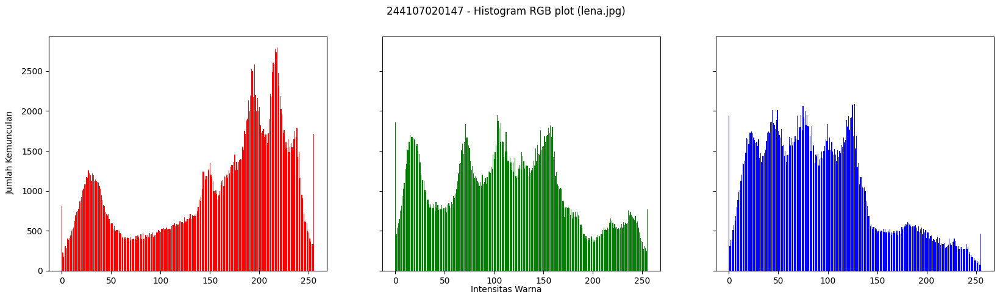

In [5]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK2026/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (lena.jpg)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

- Tahap 2: KTP1b.jpeg

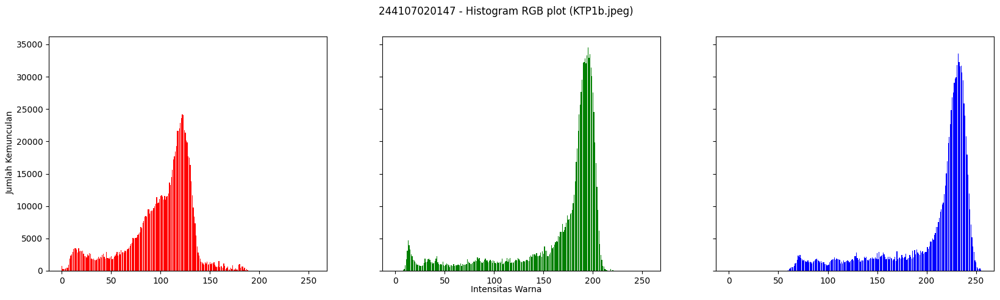

In [6]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK2026/KTP1b.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (KTP1b.jpeg)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

### **PERTANYAAN PRAKTIKUM E1**
1. **Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.**<br><br>
- Tahap 1 : lena.jpg

In [7]:
def histogram_manual(img_gray):
    h = np.zeros(256, dtype=np.int64)
    for y in range(img_gray.shape[0]):
        for x in range(img_gray.shape[1]):
            h[img_gray[y, x]] += 1
    return h

lena.jpg
Selisih maksimum manual vs numpy.histogram      : 0
Selisih maksimum manual vs cv.calcHist          : 0
Selisih maksimum numpy.histogram vs cv.calcHist : 0


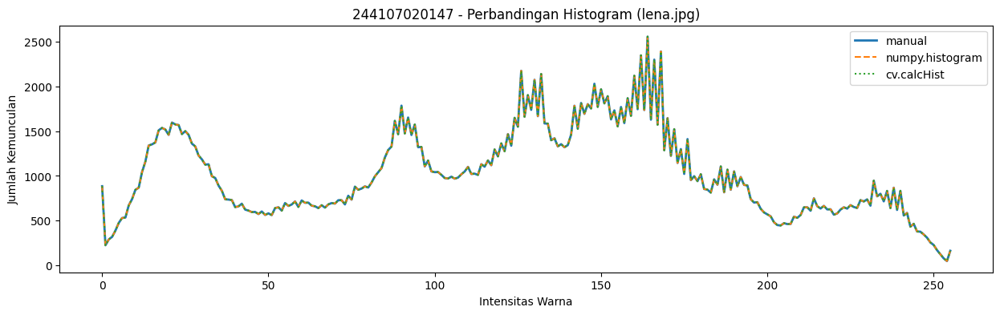

In [8]:
gray = cv.imread('/content/drive/MyDrive/PCVK2026/lena.jpg', cv.IMREAD_GRAYSCALE)

h_manual = histogram_manual(gray)
h_numpy, _ = np.histogram(gray, bins=256, range=(0, 256))
h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

selisih_manual_numpy = np.max(np.abs(h_manual - h_numpy))
selisih_manual_cv    = np.max(np.abs(h_manual - h_cv))
selisih_numpy_cv     = np.max(np.abs(h_numpy - h_cv))

print('lena.jpg')
print('Selisih maksimum manual vs numpy.histogram      :', selisih_manual_numpy)
print('Selisih maksimum manual vs cv.calcHist          :', selisih_manual_cv)
print('Selisih maksimum numpy.histogram vs cv.calcHist :', selisih_numpy_cv)

plt.figure(figsize=(15,4))
plt.plot(h_manual, label='manual', linewidth=2)
plt.plot(h_numpy, label='numpy.histogram', linestyle='--')
plt.plot(h_cv, label='cv.calcHist', linestyle=':')
plt.title(NIM + ' - Perbandingan Histogram (lena.jpg)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.show()

- Tahap 2 : KTP1b.jpeg

KTP1b.jpeg
Selisih maksimum manual vs numpy.histogram      : 0
Selisih maksimum manual vs cv.calcHist          : 0
Selisih maksimum numpy.histogram vs cv.calcHist : 0


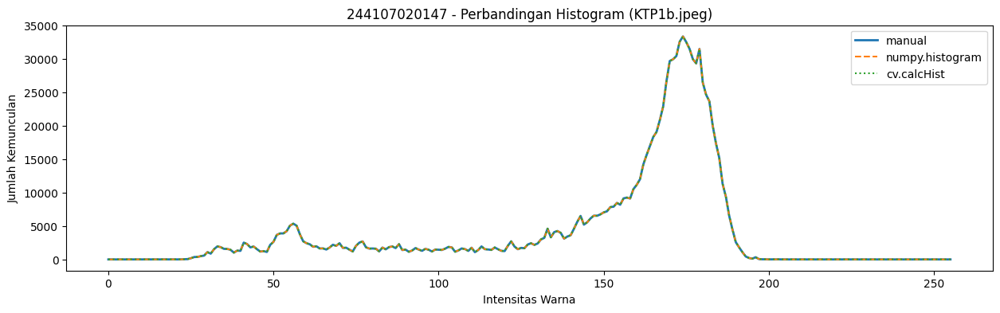

In [9]:
gray = cv.imread('/content/drive/MyDrive/PCVK2026/KTP1b.jpeg', cv.IMREAD_GRAYSCALE)

h_manual = histogram_manual(gray)
h_numpy, _ = np.histogram(gray, bins=256, range=(0, 256))
h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

selisih_manual_numpy = np.max(np.abs(h_manual - h_numpy))
selisih_manual_cv    = np.max(np.abs(h_manual - h_cv))
selisih_numpy_cv     = np.max(np.abs(h_numpy - h_cv))

print('KTP1b.jpeg')
print('Selisih maksimum manual vs numpy.histogram      :', selisih_manual_numpy)
print('Selisih maksimum manual vs cv.calcHist          :', selisih_manual_cv)
print('Selisih maksimum numpy.histogram vs cv.calcHist :', selisih_numpy_cv)

plt.figure(figsize=(15,4))
plt.plot(h_manual, label='manual', linewidth=2)
plt.plot(h_numpy, label='numpy.histogram', linestyle='--')
plt.plot(h_cv, label='cv.calcHist', linestyle=':')
plt.title(NIM + ' - Perbandingan Histogram (KTP1b.jpeg)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.show()

**Penjelasan:** <br>
Ketiga metode (manual, numpy.histogram, cv.calcHist) menghasilkan selisih maksimum 0 pada lena.jpg maupun KTP1b, karena ketiganya menghitung hal yang sama yaitu jumlah kemunculan tiap nilai intensitas piksel. Perbedaannya hanya di kecepatan proses, metode manual jauh lebih lambat karena mengecek piksel satu per satu, sedangkan numpy.histogram dan cv.calcHist sudah dioptimasi sehingga jauh lebih cepat.

2. **Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.**

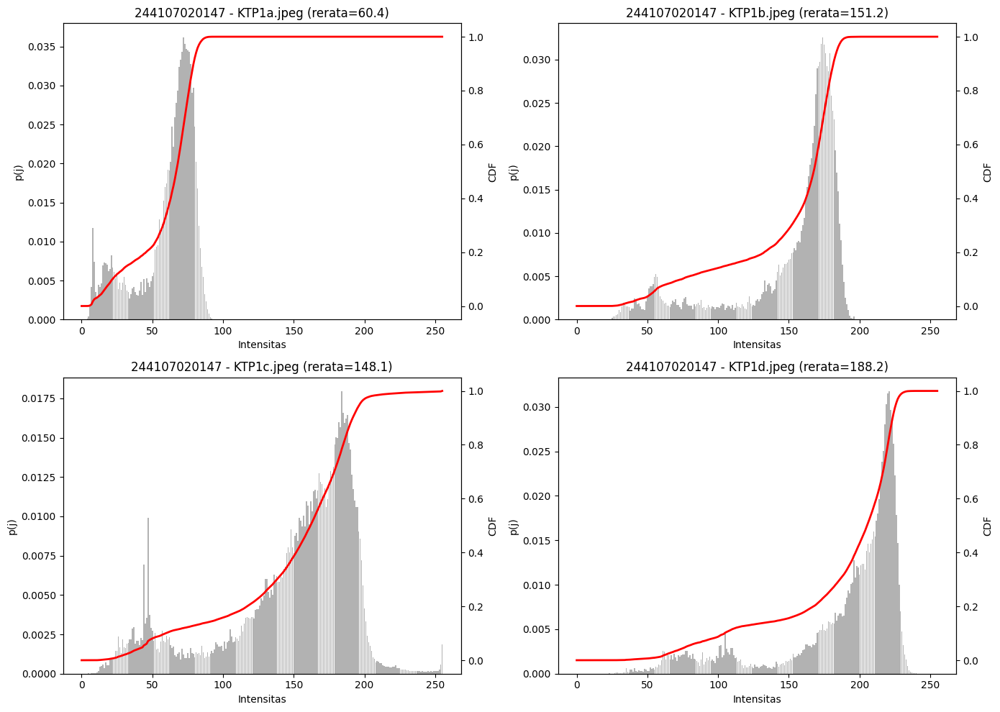

Rerata kecerahan tiap citra:
  KTP1a.jpeg: 60.44
  KTP1b.jpeg: 151.17
  KTP1c.jpeg: 148.10
  KTP1d.jpeg: 188.24


In [10]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

files = ['KTP1a.jpeg', 'KTP1b.jpeg', 'KTP1c.jpeg', 'KTP1d.jpeg']

rerata_kecerahan = {}

for i, fname in enumerate(files):
    gray = cv.imread(BASE + '/' + fname, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size           # normalisasi
    cdf = np.cumsum(p)          # distribusi kumulatif

    rerata_kecerahan[fname] = gray.mean()

    ax2 = axs[i].twinx()
    axs[i].bar(np.arange(256), p, color='gray', alpha=0.6, label='p(j)')
    ax2.plot(np.arange(256), cdf, color='red', linewidth=2, label='CDF')

    axs[i].set_title(NIM + f' - {fname} (rerata={gray.mean():.1f})')
    axs[i].set_xlabel('Intensitas')
    axs[i].set_ylabel('p(j)')
    ax2.set_ylabel('CDF')

plt.tight_layout()
plt.show()

print('Rerata kecerahan tiap citra:')
for k, v in rerata_kecerahan.items():
    print(f'  {k}: {v:.2f}')

**Penjelasan:**<br>
Dari hasil pengamatan histogram ternormalisasi p(j) dan kurva CDF pada keempat citra KTP, diperoleh rerata kecerahan sebagai berikut:
- KTP1a (ruangan gelap) = 60,4
- KTP1b (lampu ruangan) = 151,2
- KTP1c (flash) = 148,1
- KTP1d (cahaya matahari) = 188,2

Kurva CDF pada KTP1a melonjak curam di sisi kiri (intensitas rendah) karena mayoritas piksel gelap, sedangkan pada KTP1d kurva tetap landai hingga intensitas tinggi baru melonjak, karena mayoritas piksel terang. Posisi lonjakan CDF ini sejalan dengan kondisi pencahayaan saat akuisisi, gelap membuat CDF naik di kiri, terang membuat CDF naik di kanan.

3. **Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.**

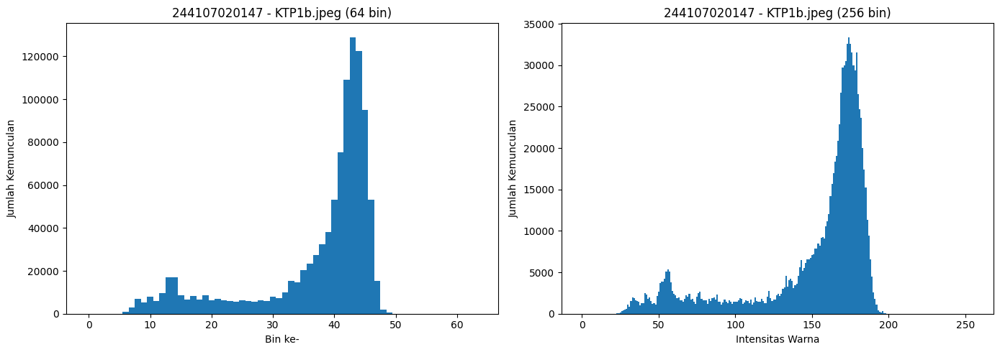

In [11]:
gray = cv.imread(BASE + '/' + 'KTP1b.jpeg', cv.IMREAD_GRAYSCALE)

h_bins = cv.calcHist([gray], [0], None, [PARAM['bins']], [0, 256]).flatten()
h_256  = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()

fig, axs = plt.subplots(1, 2, figsize=(14,5))

axs[0].bar(np.arange(PARAM['bins']), h_bins, width=1.0)
axs[0].set_title(NIM + ' - KTP1b.jpeg (%d bin)' % PARAM['bins'])
axs[0].set_xlabel('Bin ke-')
axs[0].set_ylabel('Jumlah Kemunculan')

axs[1].bar(np.arange(256), h_256, width=1.0)
axs[1].set_title(NIM + ' - KTP1b.jpeg (256 bin)')
axs[1].set_xlabel('Intensitas Warna')
axs[1].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

**Penjelasan:**<br>
Histogram 64 bin (PARAM['bins']) menggabungkan tiap 4 nilai intensitas berdekatan menjadi satu batang, sehingga terlihat lebih kasar/blocky dibanding histogram 256 bin yang menampilkan tiap nilai intensitas secara terpisah dan lebih detail. Meski begitu, pola umum distribusi (dua kelompok intensitas: rendah dan tinggi) tetap terlihat sama di keduanya, jadi yang hilang hanya detail fluktuasi kecil antar nilai berdekatan, bukan tren keseluruhan.

### **E-2 PERCOBAAN HISTOGRAM EQUALIZATION**
1. **Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses, berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.**
- Tahap 1 : lena_lc.jpg


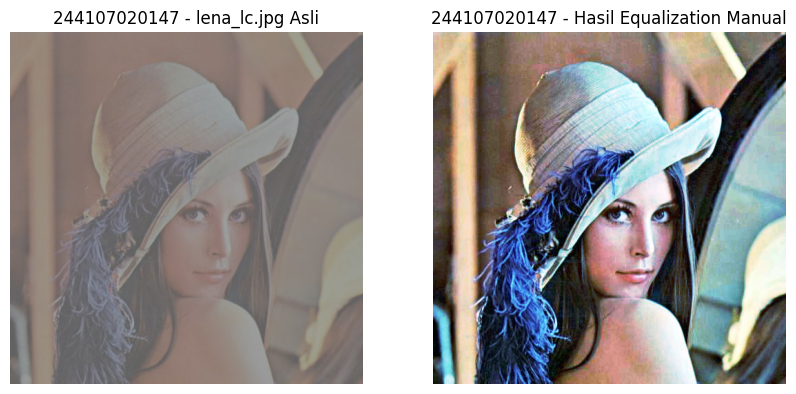

In [12]:
def histogram_equalization_manual(channel):
    h = histogram_manual(channel)
    p = h / channel.size
    cdf = np.cumsum(p)
    s = np.round(255 * cdf).astype(np.uint8)
    hasil = s[channel]
    return hasil

bgr = cv.imread(CONTOH + '/lena_lc.jpg')

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - lena_lc.jpg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Hasil Equalization Manual')
plt.axis('off')
plt.show()

- Tahap 2 : KTP1a.jpeg

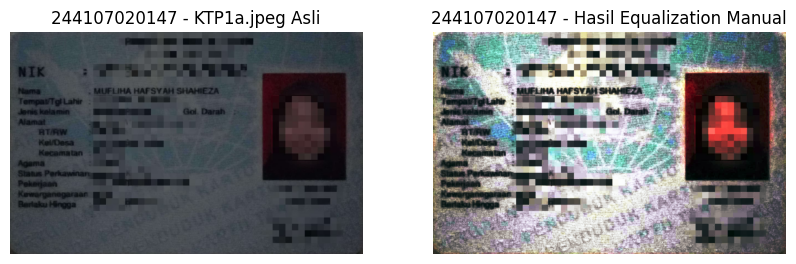

In [13]:
bgr = cv.imread(BASE + '/' + 'KTP1a.jpeg')

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTP1a.jpeg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Hasil Equalization Manual')
plt.axis('off')
plt.show()

2. **Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapivmenggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”. Bandingkan hasil equalizeHist dengan hasil
implementasi manual Anda dengan menghitung selisih maksimum antara keduanya, baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut apabila tidak nol.**

- Tahap 1 : lena_lc.jpg

Selisih maksimum manual vs cv.equalizeHist (lena_lc.jpg): 0


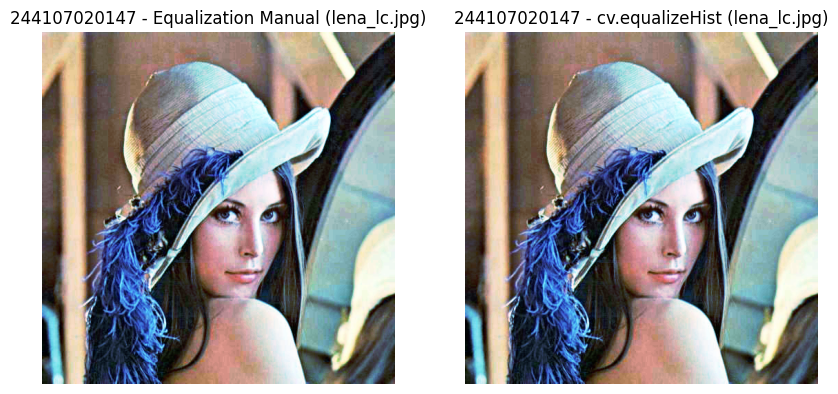

In [14]:
bgr = cv.imread(CONTOH + '/lena_lc.jpg')

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

b, g, r = cv.split(bgr)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)
hasil_cv = cv.merge([b_equalized, g_equalized, r_equalized])

selisih = np.max(np.abs(hasil_eq.astype(np.int16) - hasil_cv.astype(np.int16)))
print('Selisih maksimum manual vs cv.equalizeHist (lena_lc.jpg):', selisih)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization Manual (lena_lc.jpg)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - cv.equalizeHist (lena_lc.jpg)')
plt.axis('off')
plt.show()

- Tahap 2 : KTP1a.jpeg

Selisih maksimum manual vs cv.equalizeHist (KTP1a.jpeg): 1


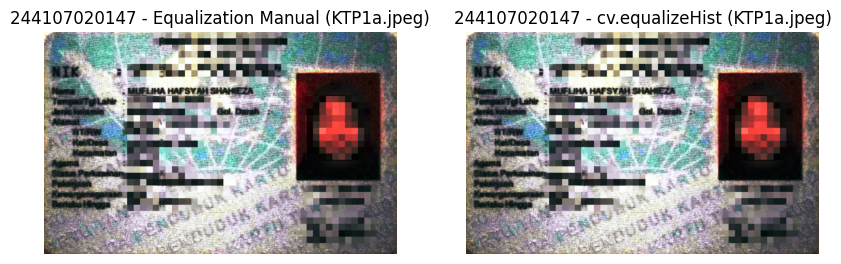

In [15]:
bgr = cv.imread(BASE + '/' + 'KTP1a.jpeg')

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

b, g, r = cv.split(bgr)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)
hasil_cv = cv.merge([b_equalized, g_equalized, r_equalized])

selisih = np.max(np.abs(hasil_eq.astype(np.int16) - hasil_cv.astype(np.int16)))
print('Selisih maksimum manual vs cv.equalizeHist (KTP1a.jpeg):', selisih)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization Manual (KTP1a.jpeg)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - cv.equalizeHist (KTP1a.jpeg)')
plt.axis('off')
plt.show()

**Penjelasan:** <br>
Perbandingan hasil equalisasi manual dengan cv.equalizeHist menunjukkan selisih maksimum sebesar 0 pada citra lena_lc.jpg dan selisih maksimum sebesar 1 pada citra KTP1a.jpeg. Selisih sebesar 1 level intensitas ini muncul akibat perbedaan kecil pada cara pembulatan (*rounding*) nilai piksel hasil transformasi.<br>
Implementasi manual menggunakan rumus s = round(255 × CDF), sedangkan cv.equalizeHist pada OpenCV menggunakan implementasi internal dengan pendekatan pembulatan yang sedikit berbeda pada kasus nilai pecahan tepat di tengah (seperti 0,5). Meskipun demikian, selisih ini sangat kecil (hanya 1 dari rentang 0-255) dan tidak memengaruhi hasil visual citra secara signifikan, sehingga kedua hasil terlihat identik secara kasat mata.

3. **Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali
terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan
potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada
KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.**
- Tahap 1 : lena.jpg

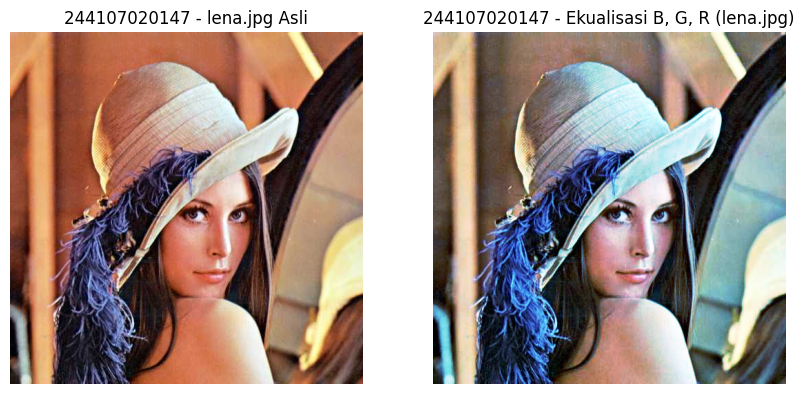

In [16]:
berkas = CONTOH + '/lena.jpg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - lena.jpg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B, G, R (lena.jpg)')
plt.axis('off')
plt.show()

- Tahap 2 : KTP1d.jpeg

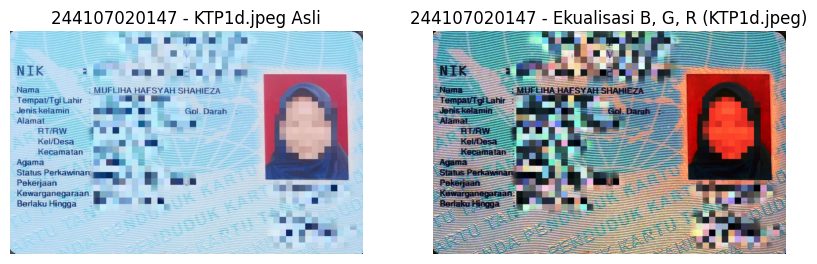

In [17]:
berkas = BASE + '/' + 'KTP1d.jpeg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTP1d.jpeg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B, G, R (KTP1d.jpeg)')
plt.axis('off')
plt.show()

**Penjelasan:** <br>
Ekualisasi tiap kanal B, G, R secara terpisah menghasilkan warna yang bergeser dari aslinya, karena tiap kanal punya distribusi histogram berbeda sehingga proses stretching-nya juga berbeda besarannya. Pada lena.jpg pergeserannya kecil, tapi pada KTP1d cukup signifikan (background biru jadi keunguan, wajah jadi oranye). Meski warna bergeser, kontras meningkat drastis sehingga teks NIK dan Nama jadi lebih mudah terbaca.

4. **Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang
menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan
KTM1d.jpg). <br> Tampilkan kelimanya berdampingan agar perbedaannya terlihat langsung.**
- Tahap 1 : lena.jpg

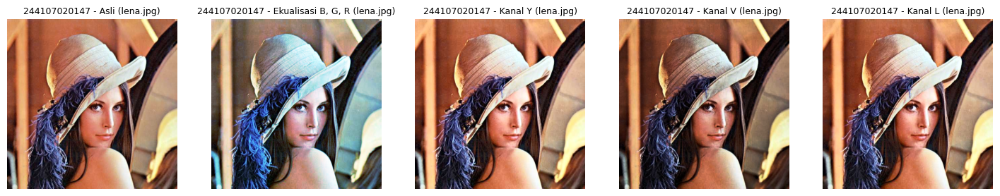

In [18]:
berkas = CONTOH + '/lena.jpg'
bgr = cv.imread(berkas)

# cara 1: tiap kanal diekualisasi sendiri-sendiri (dari Langkah 3)
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t + ' (lena.jpg)', fontsize=9)
    plt.axis('off')
plt.show()

- Tahap 2 : KTP1d.jpeg

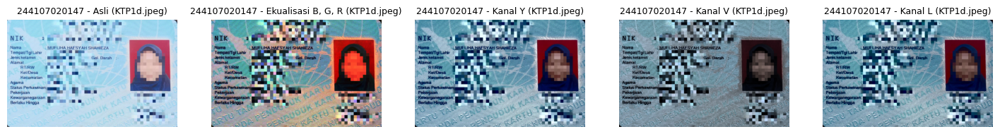

In [19]:
berkas = BASE + '/' + 'KTP1d.jpeg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t + ' (KTP1d.jpeg)', fontsize=9)
    plt.axis('off')
plt.show()

**Penjelasan:**<br>
"Ekualisasi pada kanal terang saja (Y, V, atau L) menghasilkan warna yang jauh lebih mendekati aslinya dibanding ekualisasi B, G, R terpisah, karena komponen kecerahan dipisah dari komponen warna. Pada KTP1d, background biru tetap terjaga warnanya di ketiga kanal terang, berbeda dengan hasil B, G, R yang berubah keunguan. Namun, peningkatan kontras pada teks tidak sedrastis hasil B, G, R, sehingga ada trade-off antara menjaga warna asli dan memaksimalkan kontras.

**Perbedaan kedua cara ini tidak cukup dinilai dengan mata. Ukur pergeseran warnanya dengan
membandingkan kanal Hue dengan citra asli. Kanal Hue menyimpan jenis warna, sehingga nilai yang berubah banyak berarti warna citra memang bergeser. Perhatikan bahwa Hue pada OpenCV bersifat
melingkar pada rentang 0 sampai 179, jadi selisihnya dihitung lewat jalur terpendek.**

In [20]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)   # Hue melingkar 0-179
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            188.2
Ekualisasi B, G, R                64.24            129.1
Kanal Y                            2.31            129.7
Kanal V                            1.24            112.5
Kanal L                            3.18            121.1


**Catat hasilnya pada tabel berikut.**

| Cara ekualisasi | Rata-rata pergeseran <br>Hue (derajat) | Rerata kecerahan <br>sesudah | Catatan pengamatan <br> visual |
|---|---|---|---|
| Citra asli | - | 188,2 | Warna background biru, foto wajah <br> merah gelap |
| Ekualisasi kanal B, G, R | 64,24 | 129,1 | Warna berubah drastis, background <br> jadi keunguan, wajah jadi oranye |
| Kanal Y (YCrCb) | 2,31 | 129,7 | Warna asli hampir terjaga, background <br> tetap biru |
| Kanal V (HSV) | 1,24 | 112,5 | Warna asli paling terjaga, pergeseran <br> Hue terkecil |
| Kanal L (LAB) | 3,18 | 121,1 | Warna asli terjaga, sedikit lebih bergeser <br> dari kanal V |

**Jawab pertanyaan berikut berdasarkan angka pada tabel Anda, bukan hanya dari pengamatan mata:**
1. **Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada
citra Anda?**<br>
Jawaban: <br>
Cara yang menghasilkan pergeseran Hue paling besar adalah ekualisasi kanal B, G, R secara terpisah, dengan nilai rata-rata pergeseran Hue sebesar 64,24 derajat. Nilai ini jauh lebih besar dibandingkan ketiga cara kanal terang lainnya (Kanal Y = 2,31°, Kanal V = 1,24°, Kanal L = 3,18°), yang membuktikan bahwa mengekualisasi tiap kanal warna secara independen menyebabkan pergeseran warna yang signifikan.<hr>
2. **Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR.**<br>
Jawaban:<br>
Meskipun secara teori mengekualisasi kanal terang saja (Y, V, atau L) seharusnya tidak mengubah informasi warna (Hue) sama sekali, pada praktiknya tetap terjadi pergeseran kecil (Kanal Y = 2,31°, Kanal V = 1,24°, Kanal L = 3,18°). Hal ini disebabkan oleh proses pembulatan (rounding) dan pemotongan (clipping) nilai piksel yang terjadi saat citra dikonversi bolak-balik antar ruang warna (misalnya dari BGR ke YCrCb lalu kembali ke BGR). Konversi ruang warna melibatkan operasi matematis dengan bilangan pecahan yang kemudian dibulatkan ke bilangan bulat terdekat (karena tipe data piksel adalah uint8/integer), sehingga terjadi sedikit kehilangan presisi (rounding error) pada setiap tahap konversi. Akumulasi kesalahan pembulatan inilah yang menyebabkan pergeseran Hue kecil meskipun secara konsep kanal warna tidak disentuh.<hr>
3. **Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan
alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.**<br>
Jawaban:<br>
Berdasarkan data pada tabel, Kanal V (HSV) adalah yang paling sesuai untuk foto KTP, karena menghasilkan pergeseran Hue paling kecil (1,24°), yang berarti warna asli citra (terutama warna background biru KTP dan foto wajah) paling terjaga dibandingkan Kanal Y dan Kanal L. Hal ini penting khususnya untuk mempertahankan keaslian warna dokumen identitas, seperti warna background biru khas KTP yang menjadi ciri visual dokumen tersebut. <hr>
4. **Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.**<br>
Jawaban:<br>


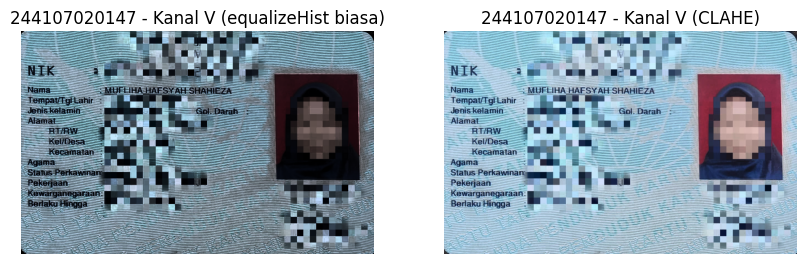

Kanal V (equalizeHist) -> geser Hue: 1.24, rerata terang: 112.5
Kanal V (CLAHE)        -> geser Hue: 0.18, rerata terang: 163.7


In [21]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
v_clahe = clahe.apply(v)
he_v_clahe = cv.cvtColor(cv.merge([h, sat, v_clahe]), cv.COLOR_HSV2BGR)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(he_v, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Kanal V (equalizeHist biasa)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(he_v_clahe, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Kanal V (CLAHE)')
plt.axis('off')
plt.show()

geser_biasa = geser_hue(bgr, he_v) * 2
geser_clahe = geser_hue(bgr, he_v_clahe) * 2
terang_biasa = cv.cvtColor(he_v, cv.COLOR_BGR2GRAY).mean()
terang_clahe = cv.cvtColor(he_v_clahe, cv.COLOR_BGR2GRAY).mean()

print('Kanal V (equalizeHist) -> geser Hue: %.2f, rerata terang: %.1f' % (geser_biasa, terang_biasa))
print('Kanal V (CLAHE)        -> geser Hue: %.2f, rerata terang: %.1f' % (geser_clahe, terang_clahe))

**Perbandingan:**<br>
Perbandingan antara ekualisasi kanal V menggunakan equalizeHist biasa dan CLAHE (clipLimit=2,0, tileGridSize=5×5) menunjukkan bahwa CLAHE menghasilkan pergeseran Hue yang jauh lebih kecil (0,18°) dibandingkan equalizeHist biasa (1,24°), yang berarti CLAHE mempertahankan warna asli citra jauh lebih baik. Selain itu, CLAHE juga menghasilkan rerata kecerahan yang lebih tinggi (163,7 dibanding 112,5), sehingga citra terlihat lebih terang dan detail teks pada kartu tampak lebih jelas. Hal ini terjadi karena CLAHE (Contrast Limited Adaptive Histogram Equalization) bekerja secara lokal per-tile (blok kecil citra) dengan batasan kontras (clipLimit) yang mencegah over-enhancement pada area tertentu, sehingga hasil ekualisasi lebih halus dan tidak menimbulkan distorsi warna sebesar equalizeHist global yang bekerja pada seluruh citra sekaligus tanpa mempertimbangkan variasi lokal.

### **PERTANYAAN PRAKTIKUM E2**
1. **Ekualisasi global pada citra KTM Anda**
* **a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.**
* **b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.**
* **c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.**

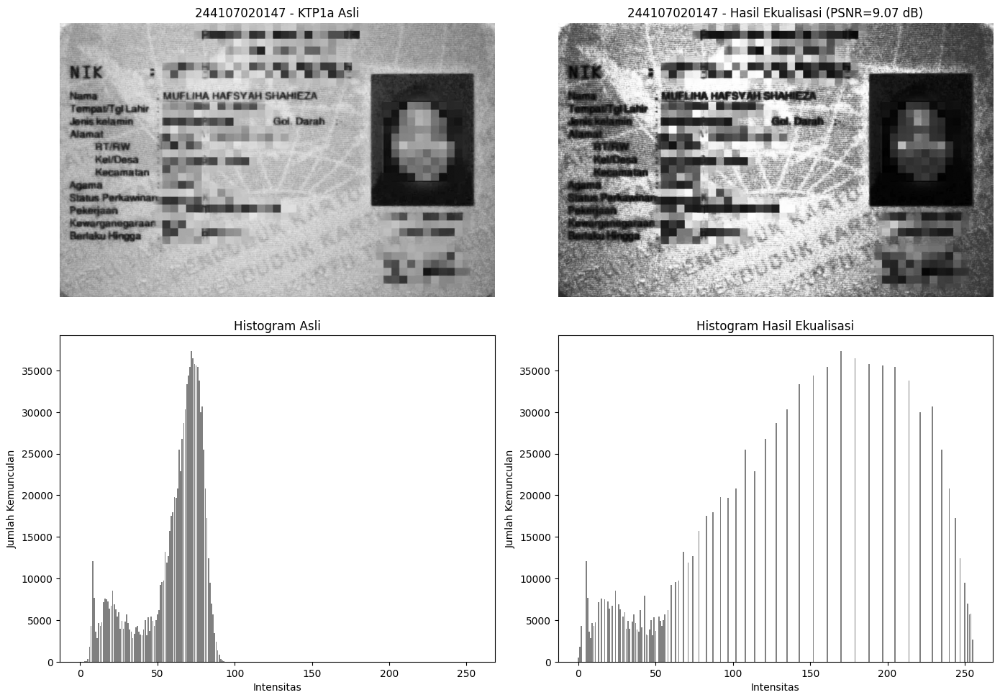

Nilai PSNR (KTP1a asli vs hasil ekualisasi): 9.07 dB


In [22]:
from math import log10, sqrt

def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

gray = cv.imread(BASE + '/' + 'KTP1a.jpeg', cv.IMREAD_GRAYSCALE)

# ekualisasi manual
hasil_manual = histogram_equalization_manual(gray)

# ekualisasi cv.equalizeHist
hasil_cv = cv.equalizeHist(gray)

# hitung histogram untuk ditampilkan
h_asli   = histogram_manual(gray)
h_hasil  = histogram_manual(hasil_cv)

# hitung PSNR
psnr_val = PSNR(gray, hasil_cv)

# tampilkan layout: citra asli, citra hasil, histogram asli, histogram hasil
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0,0].imshow(gray, cmap='gray')
axs[0,0].set_title(NIM + ' - KTP1a Asli')
axs[0,0].axis('off')

axs[0,1].imshow(hasil_cv, cmap='gray')
axs[0,1].set_title(NIM + f' - Hasil Ekualisasi (PSNR={psnr_val:.2f} dB)')
axs[0,1].axis('off')

axs[1,0].bar(np.arange(256), h_asli, color='gray')
axs[1,0].set_title('Histogram Asli')
axs[1,0].set_xlabel('Intensitas')
axs[1,0].set_ylabel('Jumlah Kemunculan')

axs[1,1].bar(np.arange(256), h_hasil, color='gray')
axs[1,1].set_title('Histogram Hasil Ekualisasi')
axs[1,1].set_xlabel('Intensitas')
axs[1,1].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

print('Nilai PSNR (KTP1a asli vs hasil ekualisasi):', round(psnr_val, 2), 'dB')

**Penjelasan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas:**<br>
PSNR hanya 9,07 dB (rendah) karena PSNR mengukur selisih nilai piksel secara matematis, bukan kejelasan visual. Histogram equalization sengaja mengubah nilai piksel secara signifikan untuk meningkatkan kontras, sehingga selisih piksel besar dan PSNR turun, meski secara visual citra jadi lebih mudah dibaca. <br><br>
**Kesimpulan: apakah PSNR layak dipakai untuk menilai keterbacaan?**<br>
PSNR tidak layak dipakai untuk menilai keterbacaan citra hasil perbaikan kontras; PSNR lebih cocok untuk menilai fidelitas/kemiripan piksel, seperti pada kasus denoising.

2. **Ekualisasi lokal dengan CLAHE pada citra KTM Anda**
* **a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?**


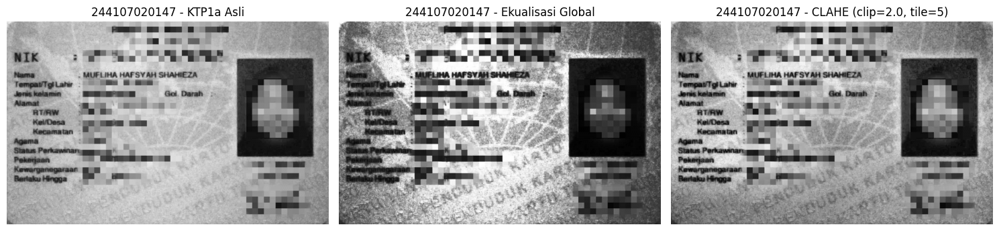

In [23]:
gray = cv.imread(BASE + '/' + 'KTP1a.jpeg', cv.IMREAD_GRAYSCALE)

hasil_global = cv.equalizeHist(gray)

clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe = clahe.apply(gray)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - KTP1a Asli')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hasil_global, cmap='gray')
plt.title(NIM + ' - Ekualisasi Global')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil_clahe, cmap='gray')
plt.title(NIM + f" - CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})")
plt.axis('off')

plt.tight_layout()
plt.show()

**Penjelasan:**<br>
CLAHE menghasilkan teks NIK dan Nama yang lebih terbaca dibanding ekualisasi global, karena ekualisasi global meningkatkan kontras seragam ke seluruh citra sehingga background watermark ikut menonjol dan mengganggu fokus. CLAHE bekerja lokal per-tile dengan batasan kontras, sehingga peningkatan lebih merata dan halus.

* **b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.**

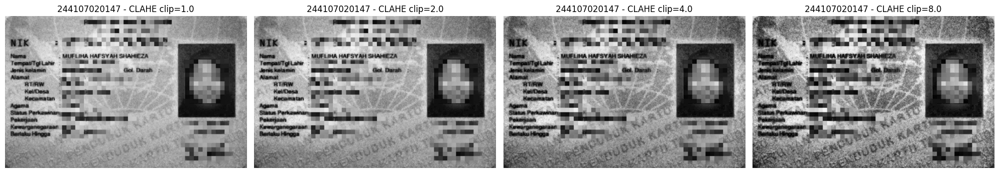

In [24]:
gray = cv.imread(BASE + '/' + 'KTP1a.jpeg', cv.IMREAD_GRAYSCALE)

clip_list = [1.0, 2.0, 4.0, 8.0]  # PARAM['clip']=2.0 disertakan sebagai pembanding

plt.figure(figsize=(20,5))
for i, clip_val in enumerate(clip_list, 1):
    clahe = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe.apply(gray)

    plt.subplot(1, len(clip_list), i)
    plt.imshow(hasil, cmap='gray')
    plt.title(NIM + f' - CLAHE clip={clip_val}')
    plt.axis('off')

plt.tight_layout()
plt.show()

**Penjelasan:**<br>
Semakin tinggi clipLimit, kontras makin kuat tapi noise juga makin menonjol, terutama di background watermark, mulai terlihat jelas pada clip=4,0 dan paling menonjol di clip=8,0. Nilai clip=2,0 (PARAM['clip']) dipilih sebagai terbaik karena memberi kontras cukup untuk keterbacaan teks tanpa noise berlebihan seperti pada clip=4,0 ke atas.

### **E-3 TUGAS PRAKTIKUM DITHERING**
1. **Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].**
- Tahap 1 : lena.jpg

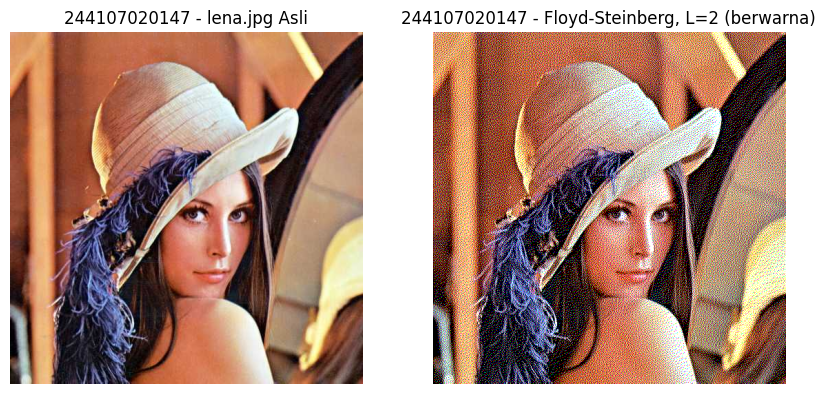

In [25]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step      # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                  img[y,   x+1] += error * 7 / 16
            if x > 0     and y+1 < H:      img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                  img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y+1 < H:      img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

bgr = cv.imread(CONTOH + '/lena.jpg')

b, g, r = cv.split(bgr)
b_dither = floyd_steinberg(b, L=2)
g_dither = floyd_steinberg(g, L=2)
r_dither = floyd_steinberg(r, L=2)
hasil_dither = cv.merge([b_dither, g_dither, r_dither])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - lena.jpg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Floyd-Steinberg, L=2 (berwarna)')
plt.axis('off')
plt.show()

- Tahap 2 : KTP1b.jpeg

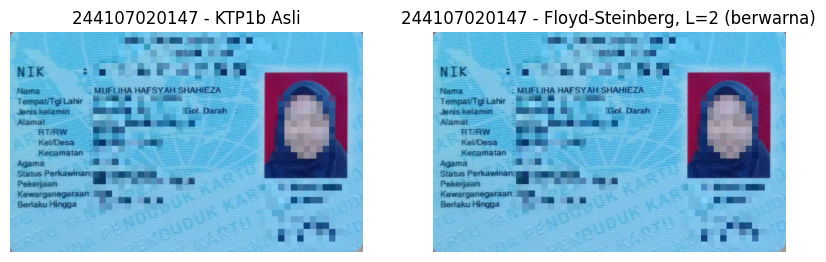

In [26]:
bgr = cv.imread(BASE + '/' + 'KTP1b.jpeg')

b, g, r = cv.split(bgr)
b_dither = floyd_steinberg(b, L=PARAM['L'])
g_dither = floyd_steinberg(g, L=PARAM['L'])
r_dither = floyd_steinberg(r, L=PARAM['L'])
hasil_dither = cv.merge([b_dither, g_dither, r_dither])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTP1b Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + f" - Floyd-Steinberg, L={PARAM['L']} (berwarna)")
plt.axis('off')
plt.show()

**Penjelasan:**<br>
Dithering diterapkan per kanal warna (B, G, R) lalu digabung kembali. Hasil pada lena.jpg cocok dengan contoh modul, membuktikan kode sudah benar. Pada KTP1b dengan PARAM['L']=2 (2 level per kanal, total 8 kombinasi warna), teks NIK dan Nama tetap terbaca dan warna dasar kartu (biru khas KTP) masih dikenali, meski kedalaman warna dipangkas drastis dari jutaan warna menjadi hanya 8 warna berkat teknik error diffusion.

2. **Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.**
- Tahap 1 : lena_lc.jpg

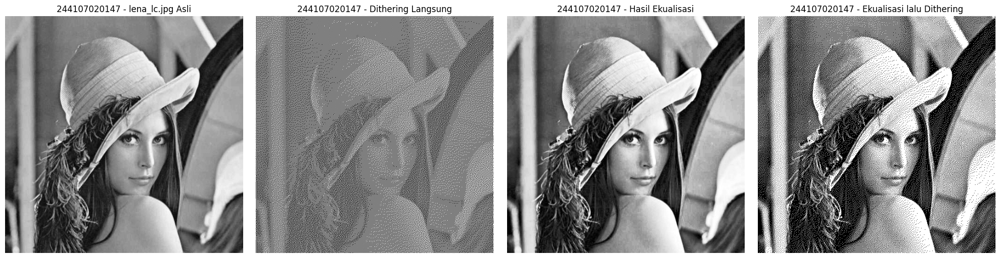

In [27]:
gray = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)

hasil_langsung = floyd_steinberg(gray, L=2)

hasil_eq = cv.equalizeHist(gray)
hasil_eq_dither = floyd_steinberg(hasil_eq, L=2)

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - lena_lc.jpg Asli')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(hasil_langsung, cmap='gray')
plt.title(NIM + ' - Dithering Langsung')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(hasil_eq, cmap='gray')
plt.title(NIM + ' - Hasil Ekualisasi')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(hasil_eq_dither, cmap='gray')
plt.title(NIM + ' - Ekualisasi lalu Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

- Tahap 2 : KTP1a.jpeg

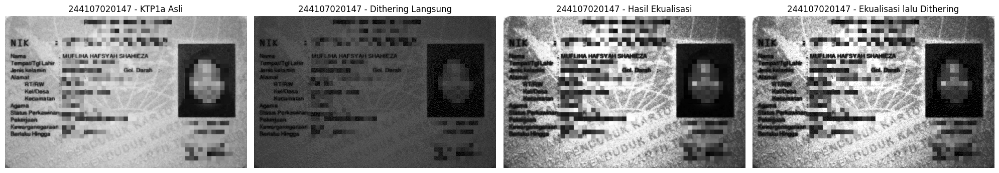

In [28]:
gray = cv.imread(BASE + '/' + 'KTP1a.jpeg', cv.IMREAD_GRAYSCALE)

hasil_langsung = floyd_steinberg(gray, L=2)

hasil_eq = cv.equalizeHist(gray)
hasil_eq_dither = floyd_steinberg(hasil_eq, L=2)

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - KTP1a Asli')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(hasil_langsung, cmap='gray')
plt.title(NIM + ' - Dithering Langsung')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(hasil_eq, cmap='gray')
plt.title(NIM + ' - Hasil Ekualisasi')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(hasil_eq_dither, cmap='gray')
plt.title(NIM + ' - Ekualisasi lalu Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

**Penjelasan:**<br>
- Pada lena_lc.jpg, dithering langsung menghasilkan detail kurang tajam karena citra sumber masih rendah kontras. Setelah diekualisasi dulu, hasil dithering-nya jadi lebih tajam dan jelas, menjadi dasar verifikasi sebelum diuji pada KTP1a
- Dithering langsung pada KTP1a tetap gelap dan kurang terbaca karena citra sumbernya rendah kontras (ruangan gelap), sedangkan dithering hanya mengkuantisasi nilai yang ada tanpa menambah kontras. Ekualisasi dulu baru dithering menghasilkan teks yang jauh lebih terbaca, karena kontras sudah diperbaiki sebelum dithering bekerja. Kesimpulannya, urutan ekualisasi lalu dithering lebih baik untuk citra kontras rendah seperti KTP1a.